In [1]:
import os
import sys
# Get the root directory (parent of 'notebooks/')
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
from model import train
from model import tests

In [5]:
tests.test_forward_passes()

CodeSimLinearCLS output shape: torch.Size([1, 1])
CodeSimSBertLinearCLS output shape: torch.Size([1, 1])
CodeSimSBertTripletENC output shape: torch.Size([1, 768])
CodeSimCombinedModel output shape: torch.Size([1, 768])
CodeSimCombinedModel output shape: torch.Size([3, 256]) torch.Size([2, 2]) [train pass]


In [ ]:
config = train.configs.TripletCodeSimClassifierConfig()
config.num_rows = 10
config.bs = 1

train.finetune_model_triplet(config=config)

Pretrained checkpoint name: huggingface/CodeBERTa-small-v1
Initializing tokenizer.
Initializing bert model.
Creating CodeNet dataset. Data type: paired
       problem_id submission_id    status                    code
count      128400        128400    128400                  128400
unique        428        128400         2                  125189
top        p03711    s543499340  Accepted  print(int(input())**2)
freq          300             1     85600                      22
Splitting dataset...
Train size: 102720, Valid size: 12840, Test size: 12840
EPOCH 1/4


  0%|          | 0/10 [00:00<?, ?it/s]

/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Iteration 2/10 complete. Loss: 0.4092403054237366
Iteration 4/10 complete. Loss: 0.4129970669746399
Iteration 6/10 complete. Loss: 0.37959563732147217
Iteration 8/10 complete. Loss: 0.30893613398075104
Iteration 10/10 complete. Loss: 0.23235616087913513


  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH 4/4 complete. AVG loss: 0.08766604959964752, AVG validation loss: 0.16261559426784516
Best validation loss improved from 0.1797451600432396 to 0.16261559426784516.


100%|██████████| 10/10 [00:02<00:00,  3.52it/s]

REPORT @ threshold=0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

REPORT @ threshold=0.7
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

REPORT @ threshold=0.9
              precision    recall  f1-score   support

           0       0.20      1.00      0.33         2
           1       0.00      0.00      0.00         8

    accuracy                           0.20        10
   macro avg       0.10      0.50      0.17        10
weigh


/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

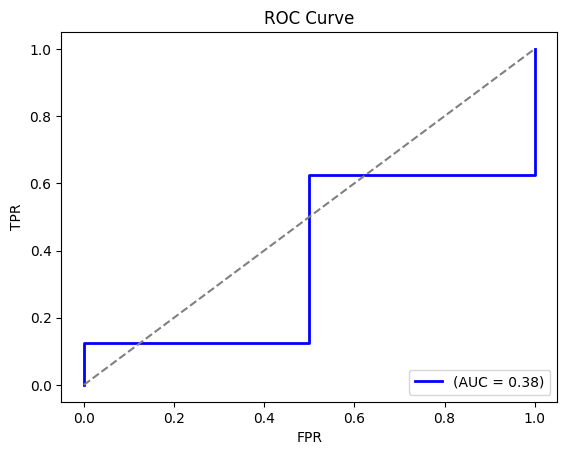

In [3]:
config = train.configs.BasicCodeSimClassifierConfig()
config.bs = 1
config.num_rows = 10
config.finetuning_strategy = "binary_cls_sbert"

train.finetune_model(config=config)

Pretrained checkpoint name: huggingface/CodeBERTa-small-v1
Initializing tokenizer.
Initializing bert model.
Creating CodeNet dataset. Data type: paired
       problem_id submission_id    status                    code
count      128400        128400    128400                  128400
unique        428        128400         2                  125189
top        p03711    s543499340  Accepted  print(int(input())**2)
freq          300             1     85600                      22
Splitting dataset...
Train size: 102720, Valid size: 12840, Test size: 12840
EPOCH 1/4


  0%|          | 0/10 [00:00<?, ?it/s]

/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Iteration 2/10 complete. Loss: 0.3231862038373947
Iteration 4/10 complete. Loss: 0.3216468095779419
Iteration 6/10 complete. Loss: 0.3016596585512161
Iteration 8/10 complete. Loss: 0.23898964375257492
Iteration 10/10 complete. Loss: 0.18092571943998337


  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH 4/4 complete. AVG loss: 0.04777297712862492, AVG validation loss: 0.08752207309007645
Best validation loss improved from 0.09819044023752213 to 0.08752207309007645.


100%|██████████| 10/10 [00:03<00:00,  3.06it/s]

REPORT @ threshold=0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

REPORT @ threshold=0.7
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10

REPORT @ threshold=0.9
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weigh


/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/peter/repos/CodeSim/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

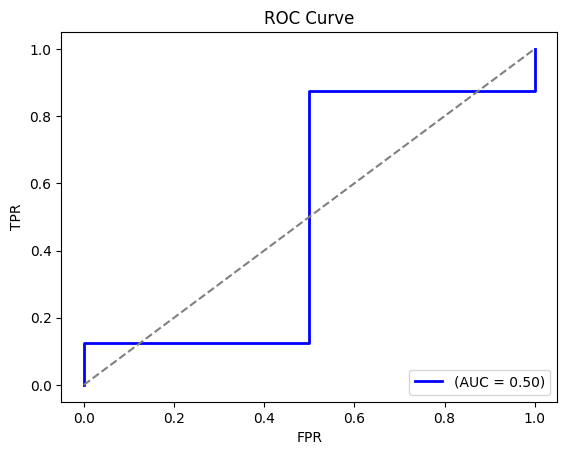

In [4]:
config = train.configs.BasicCodeSimClassifierConfig()
config.bs = 1
config.num_rows = 10
config.finetuning_strategy = "binary_cls_simpl"

train.finetune_model(config=config)